In [ ]:
# TRABAJO FIN DE GRADO - FINANZAS

In [ ]:
# íNDICE:

In [ ]:
# PASO 1

In [1]:
# ── CELDA 1: Instalación de librerías externas ─────────────────────────────────
# En Google Colab, pandas, numpy, matplotlib y seaborn ya están disponibles.
# Solo necesitamos instalar las librerías de descarga de datos externos.

!pip install yfinance pandas-datareader fredapi wbdata --quiet

print("✓ Librerías instaladas correctamente")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 300.4/300.4 kB 6.7 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
ipython 7.34.0 requires jedi>=0.16, which is not installed.
moviepy 1.0.3 requires decorator<5.0,>=4.0.2, but you have decorator 5.2.1 which is incompatible.
✓ Librerías instaladas correctamente


In [2]:
# ── CELDA 2: Importaciones ─────────────────────────────────────────────────────
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Configuración de estilo global para todos los gráficos del TFG
plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor':   '#f8f8f8',
    'axes.grid':        True,
    'grid.color':       'white',
    'grid.linewidth':   0.8,
    'font.family':      'sans-serif',
    'axes.spines.top':  False,
    'axes.spines.right':False,
})

print("✓ Todas las librerías importadas")

✓ Todas las librerías importadas


In [3]:
# ── CELDA 3: Descarga de datos desde Yahoo Finance ─────────────────────────────
# Definimos los tickers tal como los reconoce Yahoo Finance.
# Los índices llevan el prefijo ^ y los bancos su ticker de bolsa habitual.

TICKERS = {
    # Índices bursátiles
    '^IBEX':  'IBEX 35',
    '^FCHI':  'CAC 40',

    # Bancos españoles
    'SAN.MC': 'Santander',
    'BBVA.MC':'BBVA',

    # Bancos franceses
    'BNP.PA': 'BNP Paribas',
    'GLE.PA': 'Société Générale',
}

INICIO = '2020-01-01'
FIN    = '2024-12-31'

# Descargamos el precio de cierre ajustado de todos los activos de una sola vez.
# auto_adjust=True ajusta automáticamente por splits y dividendos.
raw = yf.download(
    tickers   = list(TICKERS.keys()),
    start     = INICIO,
    end       = FIN,
    auto_adjust = True,
    progress  = False
)['Close']

# Renombramos columnas con nombres legibles
raw.columns = [TICKERS[col] for col in raw.columns]

print(f"✓ Datos descargados: {raw.shape[0]} sesiones × {raw.shape[1]} activos")
print(f"  Período: {raw.index[0].date()} → {raw.index[-1].date()}")
print(f"\nPrimeras filas:")
raw.head()

✓ Datos descargados: 1282 sesiones × 6 activos
  Período: 2020-01-02 → 2024-12-30

Primeras filas:


,BBVA,BNP Paribas,Société Générale,Santander,CAC 40,IBEX 35
Date,,,,,,
2020-01-02,3.503605,37.874336,25.140249,3.102349,6041.500000,9691.200195
2020-01-03,3.465209,37.421940,24.886108,3.054201,6044.160156,9646.599609
2020-01-06,3.450125,37.238155,24.683590,3.028923,6013.589844,9600.900391
2020-01-07,3.435041,37.224014,24.985382,3.014479,6012.350098,9579.799805
2020-01-08,3.467951,37.308838,25.231585,3.016484,6031.000000,9591.400391


In [4]:
# ── CELDA 4: Limpieza y preprocesamiento ──────────────────────────────────────

# Paso 1: eliminamos filas donde TODOS los activos son NaN
# (días sin negociación en ningún mercado, por ejemplo festivos internacionales)
precios = raw.dropna(how='all').copy()

# Paso 2: rellenamos NaN puntuales con el precio del día anterior (forward fill).
# Esto ocurre cuando un mercado cierra por festivo nacional pero el otro no.
# Por ejemplo: el 14 de julio (Bastille Day) los bancos franceses no cotizan
# pero los españoles sí. Forward fill mantiene el último precio conocido.
precios = precios.ffill()

# Paso 3: verificamos que no quedan NaN
nulos = precios.isnull().sum()
print("NaN restantes por activo:")
print(nulos)
print(f"\n✓ Dataset limpio: {precios.shape[0]} sesiones × {precios.shape[1]} activos")

# Paso 4: resumen estadístico inicial
print("\nEstadísticas descriptivas de precios de cierre:")
precios.describe().round(2)

NaN restantes por activo:
BBVA                0
BNP Paribas         0
Société Générale    0
Santander           0
CAC 40              0
IBEX 35             0
dtype: int64

✓ Dataset limpio: 1282 sesiones × 6 activos

Estadísticas descriptivas de precios de cierre:


,BBVA,BNP Paribas,Société Générale,Santander,CAC 40,IBEX 35
count,1282.00,1282.00,1282.00,1282.00,1282.00,1282.00
mean,4.84,41.60,19.70,2.83,6563.48,8987.49
std,2.17,10.51,4.49,0.82,964.09,1316.13
min,1.57,17.44,8.66,1.23,3754.84,6107.20
25%,3.34,35.88,18.03,2.32,6014.07,8163.50
50%,4.15,41.53,20.80,2.72,6677.29,8866.90
75%,6.28,49.75,22.81,3.27,7315.07,9572.25
max,9.74,62.10,29.84,4.63,8239.99,12118.70


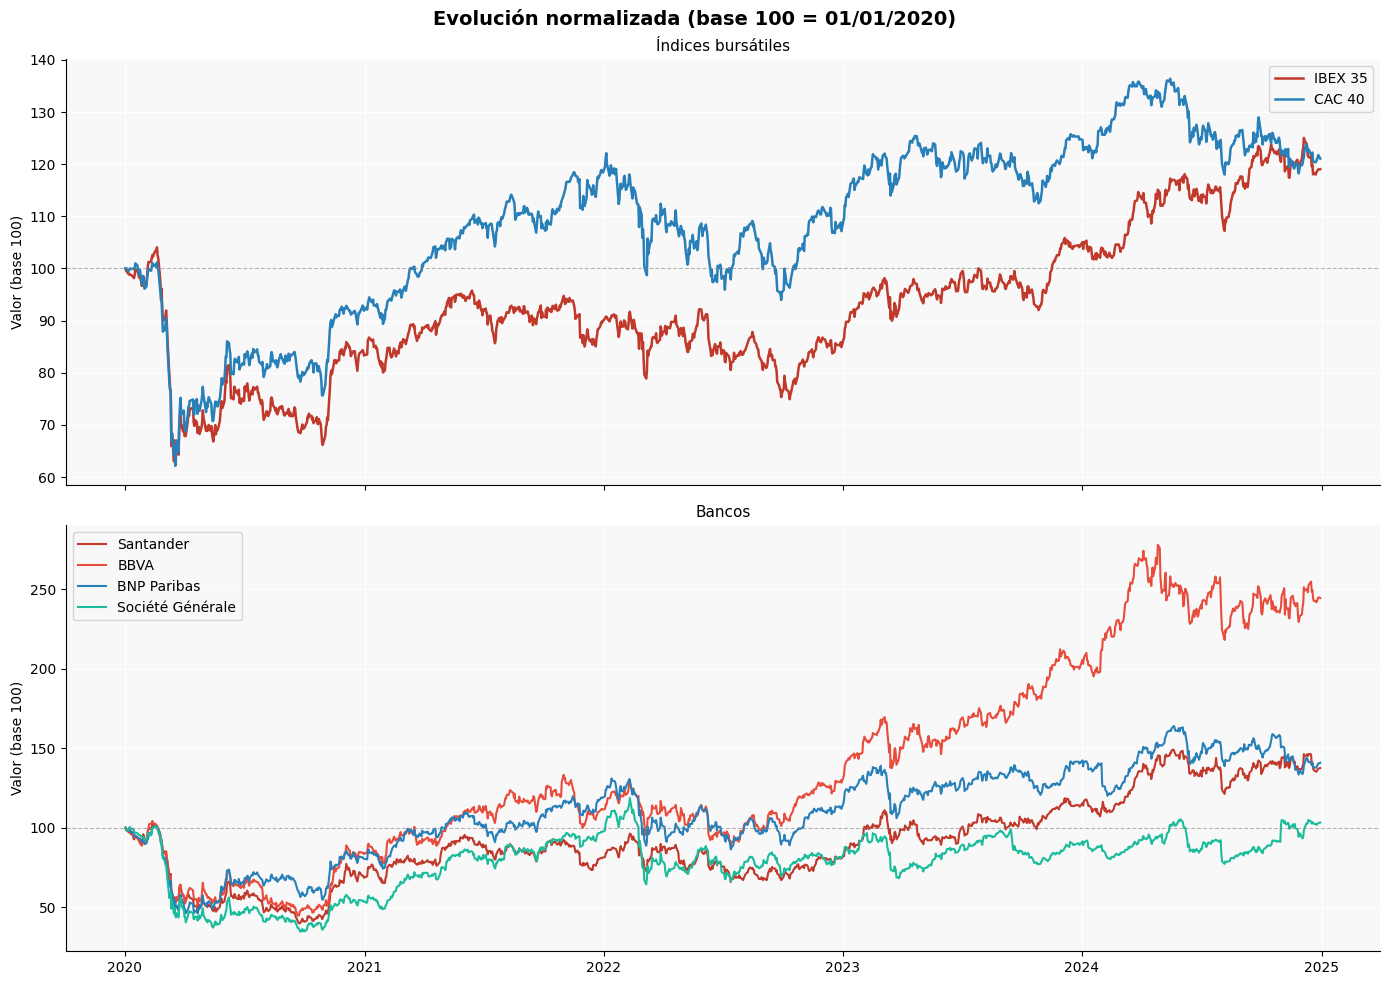

✓ Gráfico guardado como evolucion_base100.png


In [5]:
# ── CELDA 5: Normalización a base 100 (01/01/2020) ────────────────────────────
# Para comparar visualmente activos con precios muy distintos (el IBEX en 9.000
# puntos y SocGen en 20 €), los normalizamos dividiendo cada serie por su primer
# valor y multiplicando por 100. Así todos parten de 100 el 2 de enero de 2020
# y podemos comparar rendimientos relativos directamente.

base_100 = (precios / precios.iloc[0]) * 100

# Visualización: evolución normalizada de todos los activos
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10), sharex=True)
fig.suptitle('Evolución normalizada (base 100 = 01/01/2020)', fontsize=14, fontweight='bold', y=0.98)

# Panel superior: índices
colores_indices = {'IBEX 35': '#C0392B', 'CAC 40': '#2980B9'}
for col, color in colores_indices.items():
    ax1.plot(base_100.index, base_100[col], label=col, color=color, linewidth=1.8)
ax1.axhline(100, color='gray', linestyle='--', linewidth=0.8, alpha=0.6)
ax1.set_title('Índices bursátiles', fontsize=11)
ax1.set_ylabel('Valor (base 100)')
ax1.legend()

# Panel inferior: bancos
colores_bancos = {
    'Santander':        '#C0392B',
    'BBVA':             '#E74C3C',
    'BNP Paribas':      '#2980B9',
    'Société Générale': '#1ABC9C',
}
for col, color in colores_bancos.items():
    ax2.plot(base_100.index, base_100[col], label=col, color=color, linewidth=1.5)
ax2.axhline(100, color='gray', linestyle='--', linewidth=0.8, alpha=0.6)
ax2.set_title('Bancos', fontsize=11)
ax2.set_ylabel('Valor (base 100)')
ax2.legend()
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

plt.tight_layout()
plt.savefig('evolucion_base100.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Gráfico guardado como evolucion_base100.png")

In [6]:
# Paso 2

In [7]:
# ── CELDA 6: Cálculo de retornos logarítmicos ─────────────────────────────────
# Usamos retornos logarítmicos (log-returns) en lugar de retornos simples por tres razones:
#   1. Son aditivos en el tiempo: r_total = r1 + r2 + ... + rn
#   2. Mejor comportamiento estadístico (más simétricos, más normales)
#   3. Estándar en la literatura financiera académica

retornos = np.log(precios / precios.shift(1)).dropna()

# Verificación rápida
print(f"✓ Retornos calculados: {retornos.shape[0]} observaciones")
print(f"\nEstadísticas de retornos diarios:")
print(retornos.describe().round(4))

✓ Retornos calculados: 1281 observaciones

Estadísticas de retornos diarios:
            BBVA  BNP Paribas  Société Générale  Santander     CAC 40  \
count  1281.0000    1281.0000         1281.0000  1281.0000  1281.0000   
mean      0.0007       0.0003            0.0000     0.0002     0.0001   
std       0.0242       0.0224            0.0269     0.0235     0.0130   
min      -0.1634      -0.1453           -0.1942    -0.1846    -0.1310   
25%      -0.0102      -0.0093           -0.0101    -0.0121    -0.0055   
50%       0.0015       0.0010            0.0006     0.0005     0.0008   
75%       0.0126       0.0114            0.0119     0.0128     0.0065   
max       0.1540       0.1654            0.1690     0.1758     0.0806   

         IBEX 35  
count  1281.0000  
mean      0.0001  
std       0.0131  
min      -0.1515  
25%      -0.0061  
50%       0.0005  
75%       0.0068  
max       0.0823  


In [8]:
# ── CELDA 7: Asimetría, curtosis y test de normalidad ─────────────────────────
# En finanzas, los retornos rara vez son normales. Esperamos:
#   - Curtosis > 3 (colas gordas: los extremos ocurren más de lo que predice
#     una distribución normal). Esto se llama leptocurtosis.
#   - Asimetría negativa (los crashes son más bruscos que los rebotes)
# El test de Jarque-Bera contrasta formalmente H0: "los retornos son normales"

from scipy.stats import jarque_bera, skew, kurtosis

resumen = []
for col in retornos.columns:
    serie = retornos[col].dropna()
    jb_stat, jb_pval = jarque_bera(serie)
    resumen.append({
        'Activo':       col,
        'Media diaria': f"{serie.mean()*100:.4f}%",
        'Vol. diaria':  f"{serie.std()*100:.4f}%",
        'Vol. anual':   f"{serie.std()*np.sqrt(252)*100:.2f}%",
        'Asimetría':    round(skew(serie), 3),
        'Curtosis':     round(kurtosis(serie), 3),   # exceso de curtosis
        'JB p-valor':   f"{jb_pval:.2e}",
        'Normal':       'NO' if jb_pval < 0.05 else 'SÍ'
    })

df_stats = pd.DataFrame(resumen).set_index('Activo')
print("Tabla de estadísticas de retornos:")
print(df_stats.to_string())

Tabla de estadísticas de retornos:
                 Media diaria Vol. diaria Vol. anual  Asimetría  Curtosis JB p-valor Normal
Activo                                                                                     
BBVA                  0.0698%     2.4202%     38.42%     -0.351     6.818   0.00e+00     NO
BNP Paribas           0.0268%     2.2408%     35.57%     -0.460     7.576   0.00e+00     NO
Société Générale      0.0025%     2.6896%     42.70%     -0.875     9.183   0.00e+00     NO
Santander             0.0249%     2.3476%     37.27%     -0.225     7.425   0.00e+00     NO
CAC 40                0.0149%     1.2962%     20.58%     -0.998    13.609   0.00e+00     NO
IBEX 35               0.0136%     1.3145%     20.87%     -1.390    18.615   0.00e+00     NO


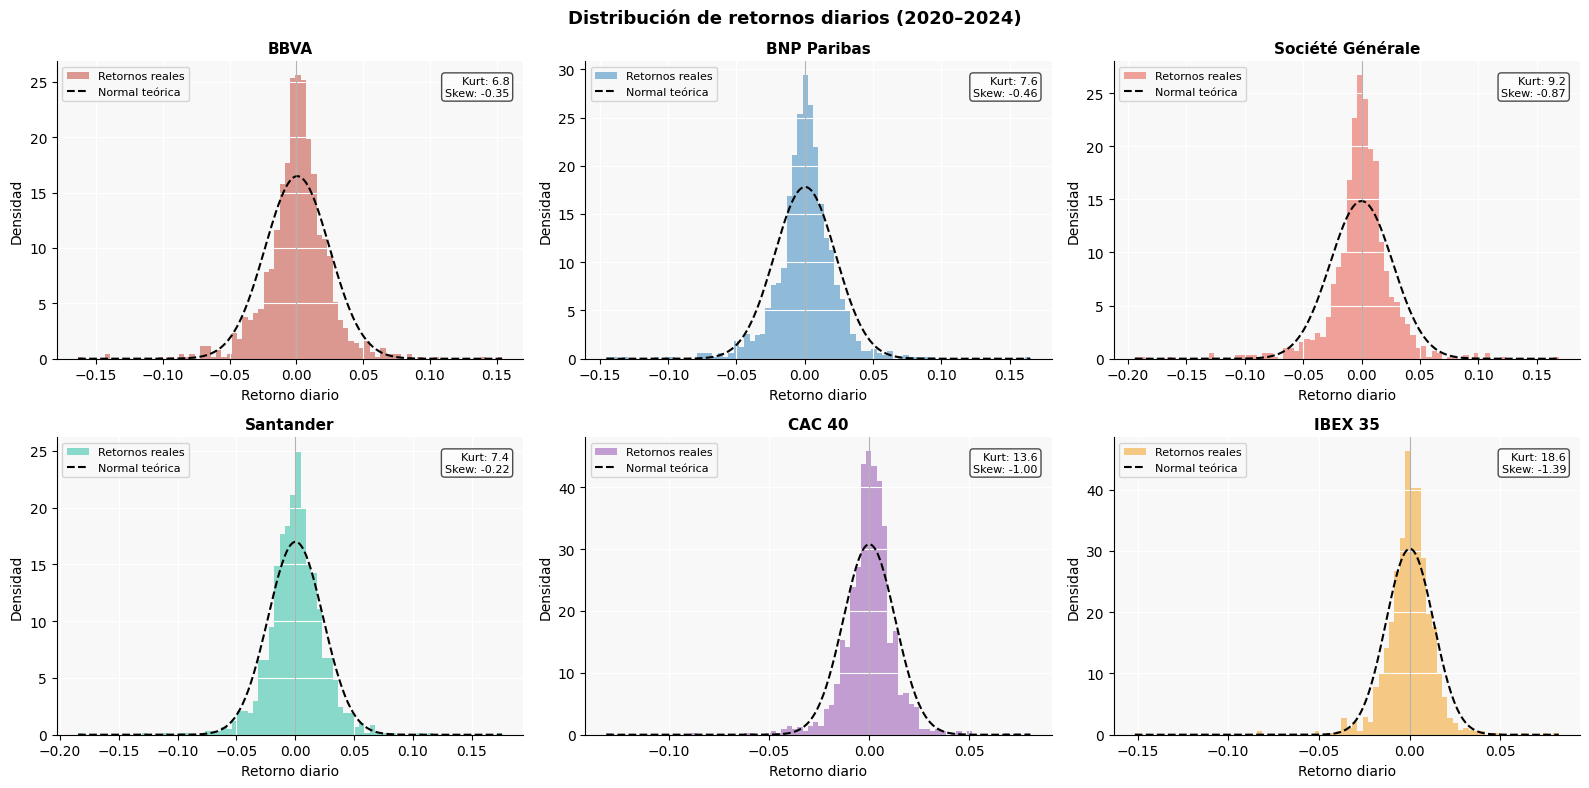

In [9]:
# ── CELDA 8: Distribución de retornos vs curva normal teórica ─────────────────
# Visualizamos cómo se distribuyen los retornos de cada activo comparados con
# lo que sería una distribución normal con la misma media y desviación típica.
# Las "colas gordas" se verán como barras que sobresalen de la curva normal.

from scipy.stats import norm

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()
colores = ['#C0392B','#2980B9','#E74C3C','#1ABC9C','#8E44AD','#F39C12']

for i, (col, color) in enumerate(zip(retornos.columns, colores)):
    serie = retornos[col].dropna()
    ax = axes[i]

    # Histograma de frecuencias
    ax.hist(serie, bins=80, density=True, color=color, alpha=0.5, label='Retornos reales')

    # Curva normal teórica superpuesta
    x = np.linspace(serie.min(), serie.max(), 300)
    ax.plot(x, norm.pdf(x, serie.mean(), serie.std()),
            'k--', linewidth=1.5, label='Normal teórica')

    # Línea vertical en 0
    ax.axvline(0, color='gray', linewidth=0.8, alpha=0.6)

    ax.set_title(col, fontsize=11, fontweight='bold')
    ax.set_xlabel('Retorno diario')
    ax.set_ylabel('Densidad')
    ax.legend(fontsize=8)

    # Anotamos curtosis y asimetría en el gráfico
    kurt_val = kurtosis(serie)
    skew_val = skew(serie)
    ax.text(0.97, 0.95, f'Kurt: {kurt_val:.1f}\nSkew: {skew_val:.2f}',
            transform=ax.transAxes, ha='right', va='top',
            fontsize=8, color='black',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.7))

plt.suptitle('Distribución de retornos diarios (2020–2024)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('histogramas_retornos.png', dpi=150, bbox_inches='tight')
plt.show()

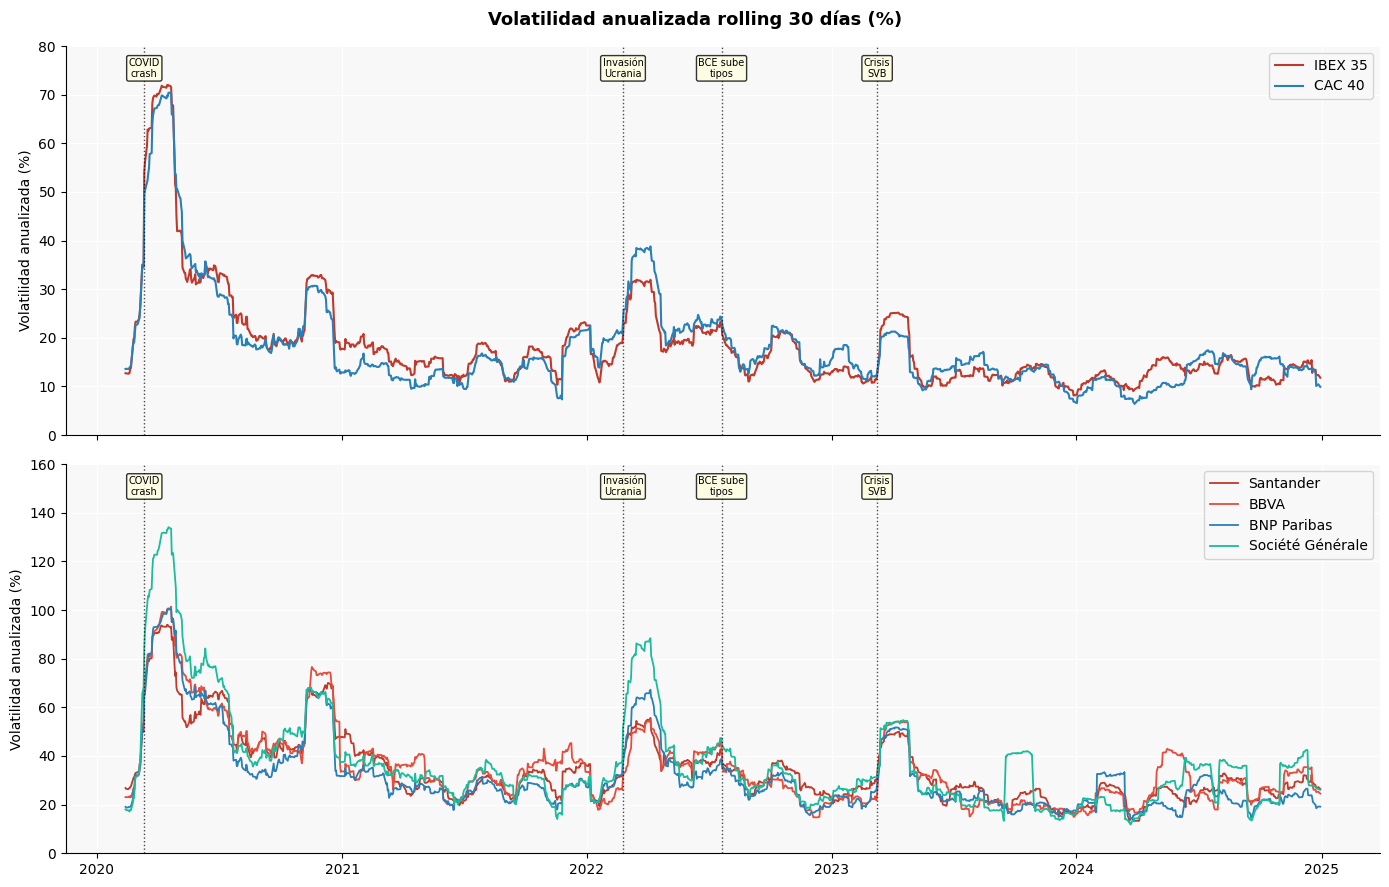

In [10]:
# ── CELDA 9: Volatilidad rolling a 30 días ────────────────────────────────────
# La volatilidad no es constante en el tiempo — se agrupa en rachas
# (efecto "volatility clustering"): períodos tranquilos seguidos de períodos
# turbulentos. Visualizarlo es clave para identificar los momentos de crisis.
# Usamos ventana de 30 días y anualización (× √252 días bursátiles/año).

vol_30d = retornos.rolling(window=30).std() * np.sqrt(252) * 100

# Eventos clave para superponer sobre el gráfico
eventos = {
    '2020-03-12': 'COVID\ncrash',
    '2022-02-24': 'Invasión\nUcrania',
    '2022-07-21': 'BCE sube\ntipos',
    '2023-03-10': 'Crisis\nSVB',
}

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 9), sharex=True)
fig.suptitle('Volatilidad anualizada rolling 30 días (%)', fontsize=13, fontweight='bold')

# Panel 1: índices
for col, color in [('IBEX 35','#C0392B'), ('CAC 40','#2980B9')]:
    ax1.plot(vol_30d.index, vol_30d[col], label=col, color=color, linewidth=1.5)
ax1.set_ylabel('Volatilidad anualizada (%)')
ax1.set_ylim(0, 80)
ax1.legend()

# Panel 2: bancos
for col, color in [('Santander','#C0392B'),('BBVA','#E74C3C'),
                   ('BNP Paribas','#2980B9'),('Société Générale','#1ABC9C')]:
    ax2.plot(vol_30d.index, vol_30d[col], label=col, color=color, linewidth=1.3)
ax2.set_ylabel('Volatilidad anualizada (%)')
ax2.set_ylim(0, 160)
ax2.legend()

# Añadimos líneas verticales de eventos en ambos paneles
for fecha, etiqueta in eventos.items():
    for ax in [ax1, ax2]:
        ax.axvline(pd.Timestamp(fecha), color='black',
                   linestyle=':', linewidth=1, alpha=0.7)
        ax.text(pd.Timestamp(fecha), ax.get_ylim()[1]*0.92,
                etiqueta, fontsize=7, ha='center',
                bbox=dict(boxstyle='round,pad=0.2', facecolor='lightyellow', alpha=0.8))

plt.tight_layout()
plt.savefig('volatilidad_rolling.png', dpi=150, bbox_inches='tight')
plt.show()

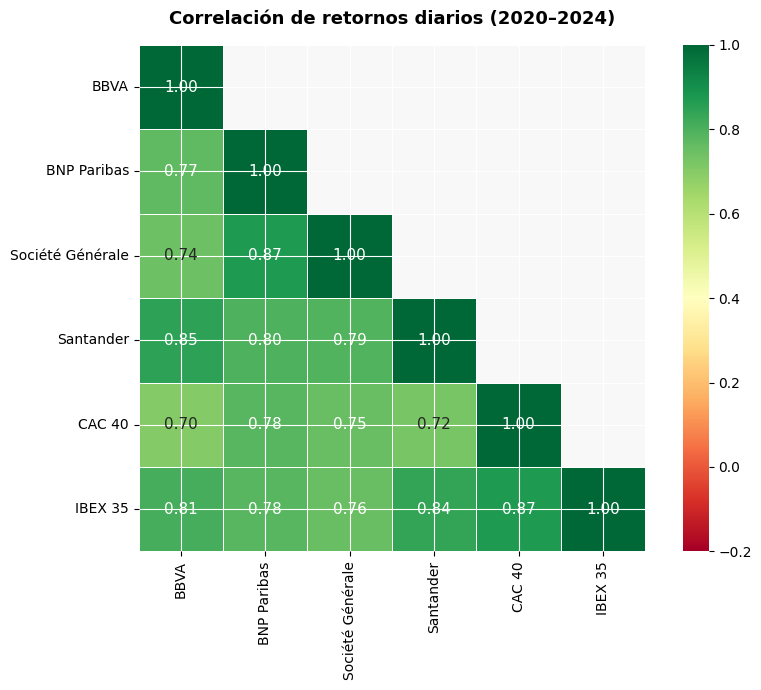


Pares con mayor correlación:
CAC 40            IBEX 35             0.870
IBEX 35           CAC 40              0.870
BNP Paribas       Société Générale    0.869
Société Générale  BNP Paribas         0.869
BBVA              Santander           0.847
Santander         BBVA                0.847
dtype: float64


In [11]:
# ── CELDA 10: Heatmap de correlación entre activos ────────────────────────────
# Calculamos la correlación de Pearson entre los retornos diarios de los 6
# activos. Una correlación alta (>0.8) indica que los activos se mueven juntos;
# baja (<0.5) indica diversificación real entre mercados.

corr_matrix = retornos.corr()

fig, ax = plt.subplots(figsize=(9, 7))

# Máscara para mostrar solo el triángulo inferior (evita duplicados)
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)

sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,          # Muestra los valores numéricos
    fmt='.2f',
    cmap='RdYlGn',       # Rojo=correlación negativa, Verde=positiva
    vmin=-0.2, vmax=1.0,
    linewidths=0.5,
    linecolor='white',
    square=True,
    ax=ax,
    annot_kws={'size': 11}
)

ax.set_title('Correlación de retornos diarios (2020–2024)', fontsize=13, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('correlacion_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

# Imprimimos también los pares más y menos correlacionados
print("\nPares con mayor correlación:")
corr_pairs = corr_matrix.unstack().sort_values(ascending=False)
corr_pairs = corr_pairs[corr_pairs < 0.9999]  # Excluir autocorrelaciones
print(corr_pairs.head(6).round(3))

In [12]:
# Capítulo 4

In [13]:
# ── CELDA 11: Parámetros base para KPIs ───────────────────────────────────────
# El tipo libre de riesgo es el rendimiento que obtienes sin asumir riesgo.
# Usamos la media del tipo de depósito del BCE en el período 2020–2024.
# En 2020–2021 fue negativo (-0,50%), subió a 0% en jul. 2022, hasta 4,00%
# en sep. 2023, y bajó al 3,50% en jun. 2024.
# La media aproximada del período completo es ~1,5% anual → 0,015/252 diario.

RF_ANUAL  = 0.015          # 1.5% anual — media BCE 2020-2024
RF_DIARIO = RF_ANUAL / 252 # Tipo libre de riesgo diario equivalente
TRADING_DAYS = 252         # Días bursátiles por año (estándar internacional)

print(f"Tipo libre de riesgo diario: {RF_DIARIO*100:.6f}%")
print(f"Tipo libre de riesgo anual:  {RF_ANUAL*100:.2f}%")

Tipo libre de riesgo diario: 0.005952%
Tipo libre de riesgo anual:  1.50%


In [14]:
# ── CELDA 12: Rentabilidad acumulada y CAGR ───────────────────────────────────
# CAGR = Compound Annual Growth Rate = tasa de crecimiento anual compuesta.
# Es la rentabilidad anual equivalente que, de haberse mantenido constante,
# habría producido el mismo resultado final que la inversión real.
# Fórmula: CAGR = (Precio_final / Precio_inicial)^(1/años) - 1

años = (precios.index[-1] - precios.index[0]).days / 365.25

retorno_acumulado = (precios.iloc[-1] / precios.iloc[0] - 1) * 100
cagr = ((precios.iloc[-1] / precios.iloc[0]) ** (1 / años) - 1) * 100

print("=" * 55)
print(f"{'Activo':<22} {'Ret. Acum.':>12} {'CAGR':>10}")
print("=" * 55)
for col in precios.columns:
    print(f"{col:<22} {retorno_acumulado[col]:>10.2f}%  {cagr[col]:>8.2f}%")
print("=" * 55)
print(f"\nPeríodo: {años:.2f} años")

Activo                   Ret. Acum.       CAGR
BBVA                       144.58%     19.61%
BNP Paribas                 40.90%      7.11%
Société Générale             3.30%      0.65%
Santander                   37.55%      6.59%
CAC 40                      21.06%      3.90%
IBEX 35                     19.04%      3.55%

Período: 4.99 años


In [15]:
# ── CELDA 13: Volatilidad anualizada y Ratio de Sharpe ────────────────────────
# Sharpe = (Retorno_medio_diario - Rf_diario) / Volatilidad_diaria × √252
# Multiplicamos por √252 para anualizar el ratio y hacerlo comparable entre activos con distinta frecuencia de datos.

ret_medio_anual = retornos.mean() * TRADING_DAYS
vol_anual       = retornos.std()  * np.sqrt(TRADING_DAYS)
exceso_retorno  = ret_medio_anual - RF_ANUAL
sharpe          = exceso_retorno / vol_anual

print("=" * 65)
print(f"{'Activo':<22} {'Ret. Anual':>11} {'Vol. Anual':>11} {'Sharpe':>9}")
print("=" * 65)
for col in retornos.columns:
    print(f"{col:<22} {ret_medio_anual[col]*100:>9.2f}%  "
          f"{vol_anual[col]*100:>9.2f}%  {sharpe[col]:>9.3f}")
print("=" * 65)

Activo                  Ret. Anual  Vol. Anual    Sharpe
BBVA                       17.59%      38.42%      0.419
BNP Paribas                 6.74%      35.57%      0.147
Société Générale            0.64%      42.70%     -0.020
Santander                   6.27%      37.27%      0.128
CAC 40                      3.76%      20.58%      0.110
IBEX 35                     3.43%      20.87%      0.092


In [16]:
# ── CELDA 14: Ratio de Sortino ────────────────────────────────────────────────
# El Sortino solo penaliza la volatilidad NEGATIVA (downside deviation).
# Filtramos únicamente los retornos por debajo del tipo libre de riesgo diario
# y calculamos su desviación típica — eso es el "riesgo real de pérdida".

def sortino_ratio(ret_serie, rf_diario):
    exceso = ret_serie - rf_diario
    # Solo retornos negativos respecto al umbral
    downside = exceso[exceso < 0]
    downside_dev = np.sqrt((downside**2).mean()) * np.sqrt(TRADING_DAYS)
    ret_anual = ret_serie.mean() * TRADING_DAYS
    return (ret_anual - RF_ANUAL) / downside_dev

sortino = retornos.apply(lambda s: sortino_ratio(s, RF_DIARIO))

print("Ratio de Sortino por activo:")
print("=" * 40)
for col in retornos.columns:
    print(f"  {col:<22}  {sortino[col]:>7.3f}")
print("=" * 40)

Ratio de Sortino por activo:
  BBVA                      0.398
  BNP Paribas               0.139
  Société Générale         -0.019
  Santander                 0.125
  CAC 40                    0.101
  IBEX 35                   0.084


In [17]:
# ── CELDA 15: Máximo Drawdown ─────────────────────────────────────────────────
# El drawdown mide la caída desde el máximo histórico en cada momento.
# El MÁXIMO drawdown es la peor caída sufrida en todo el período.
# También calculamos cuántos días tardó cada activo en recuperar ese máximo.

def max_drawdown_info(precio_serie):
    rolling_max = precio_serie.cummax()
    drawdown    = (precio_serie - rolling_max) / rolling_max * 100
    mdd         = drawdown.min()

    # Fecha del máximo previo al peor momento
    idx_min     = drawdown.idxmin()
    idx_max_pre = precio_serie[:idx_min].idxmax()

    # Tiempo de recuperación: primera fecha posterior al mínimo
    # donde el precio vuelve a superar el máximo previo
    precio_max_pre = precio_serie[idx_max_pre]
    recuperacion   = precio_serie[idx_min:]
    recuperado     = recuperacion[recuperacion >= precio_max_pre]

    if len(recuperado) > 0:
        dias_rec = (recuperado.index[0] - idx_min).days
        fecha_rec = recuperado.index[0].strftime('%Y-%m')
    else:
        dias_rec  = None
        fecha_rec = "No recuperado"

    return {
        'MDD (%)':       round(mdd, 2),
        'Fecha mínimo':  idx_min.strftime('%Y-%m-%d'),
        'Días recuper.': dias_rec if dias_rec else ">1825",
        'Recuperación':  fecha_rec
    }

print("=" * 75)
print(f"{'Activo':<22} {'MDD (%)':>10} {'Fecha mín.':>13} "
      f"{'Días recup.':>12} {'Recuperado':>14}")
print("=" * 75)
for col in precios.columns:
    info = max_drawdown_info(precios[col])
    print(f"{col:<22} {info['MDD (%)']:>9.2f}%  {info['Fecha mínimo']:>12}  "
          f"{str(info['Días recuper.']):>11}  {info['Recuperación']:>13}")
print("=" * 75)

Activo                    MDD (%)    Fecha mín.  Días recup.     Recuperado
BBVA                      -57.16%    2020-09-22          234        2021-05
BNP Paribas               -54.47%    2020-04-21          379        2021-05
Société Générale          -65.86%    2020-09-25          466        2022-01
Santander                 -61.12%    2020-09-23          888        2023-02
CAC 40                    -38.56%    2020-03-18          384        2021-04
IBEX 35                   -39.43%    2020-03-16         1355        2023-12


In [18]:
# ── CELDA 16: Beta y Alpha de Jensen ──────────────────────────────────────────
# Beta mide la sensibilidad del activo respecto a su mercado de referencia.
# Alpha mide si el activo ha generado rentabilidad por encima de lo que
# justifica su nivel de riesgo sistemático (según el CAPM).
#
# Para los bancos españoles usamos el IBEX 35 como mercado.
# Para los bancos franceses usamos el CAC 40 como mercado.
# Para ambos índices usamos el Eurostoxx 50 — pero como no lo descargamos,
# usamos la media IBEX/CAC como proxy del mercado europeo.

from scipy.stats import linregress

# Mercado de referencia para cada activo
mercados = {
    'Santander':        'IBEX 35',
    'BBVA':             'IBEX 35',
    'BNP Paribas':      'CAC 40',
    'Société Générale': 'CAC 40',
    'IBEX 35':          'CAC 40',   # referencia cruzada
    'CAC 40':           'IBEX 35',  # referencia cruzada
}

print("=" * 70)
print(f"{'Activo':<22} {'Mercado ref.':>14} {'Beta':>8} {'Alpha anual':>12} {'R²':>7}")
print("=" * 70)

betas  = {}
alphas = {}

for activo, mercado in mercados.items():
    y = retornos[activo].values
    x = retornos[mercado].values
    slope, intercept, r_value, p_value, std_err = linregress(x, y)
    beta_val  = slope
    alpha_val = intercept * TRADING_DAYS  # anualizar el alpha diario
    r2        = r_value**2
    betas[activo]  = beta_val
    alphas[activo] = alpha_val
    print(f"{activo:<22} {mercado:>14} {beta_val:>8.3f} "
          f"{alpha_val*100:>10.2f}%  {r2:>7.3f}")

print("=" * 70)
print("\nInterpretación Beta: >1 = amplifica mercado | <1 = amortigua mercado")

Activo                   Mercado ref.     Beta  Alpha anual      R²
Santander                     IBEX 35    1.499       1.13%    0.704
BBVA                          IBEX 35    1.493      12.47%    0.658
BNP Paribas                    CAC 40    1.350       1.67%    0.610
Société Générale               CAC 40    1.561      -5.23%    0.566
IBEX 35                        CAC 40    0.882       0.11%    0.757
CAC 40                        IBEX 35    0.858       0.82%    0.757

Interpretación Beta: >1 = amplifica mercado | <1 = amortigua mercado


TABLA RESUMEN DE KPIs — IBEX 35 vs CAC 40 (2020-2024)
                  Ret. Acumulado (%)  CAGR (%)  Vol. Anual (%)  Sharpe  Sortino   Beta  Alpha anual (%)
BBVA                          144.58     19.61           38.42   0.419    0.398  1.493            12.47
BNP Paribas                    40.90      7.11           35.57   0.147    0.139  1.350             1.67
CAC 40                         21.06      3.90           20.58   0.110    0.101  0.858             0.82
IBEX 35                        19.04      3.55           20.87   0.092    0.084  0.882             0.11
Santander                      37.55      6.59           37.27   0.128    0.125  1.499             1.13
Société Générale                3.30      0.65           42.70  -0.020   -0.019  1.561            -5.23


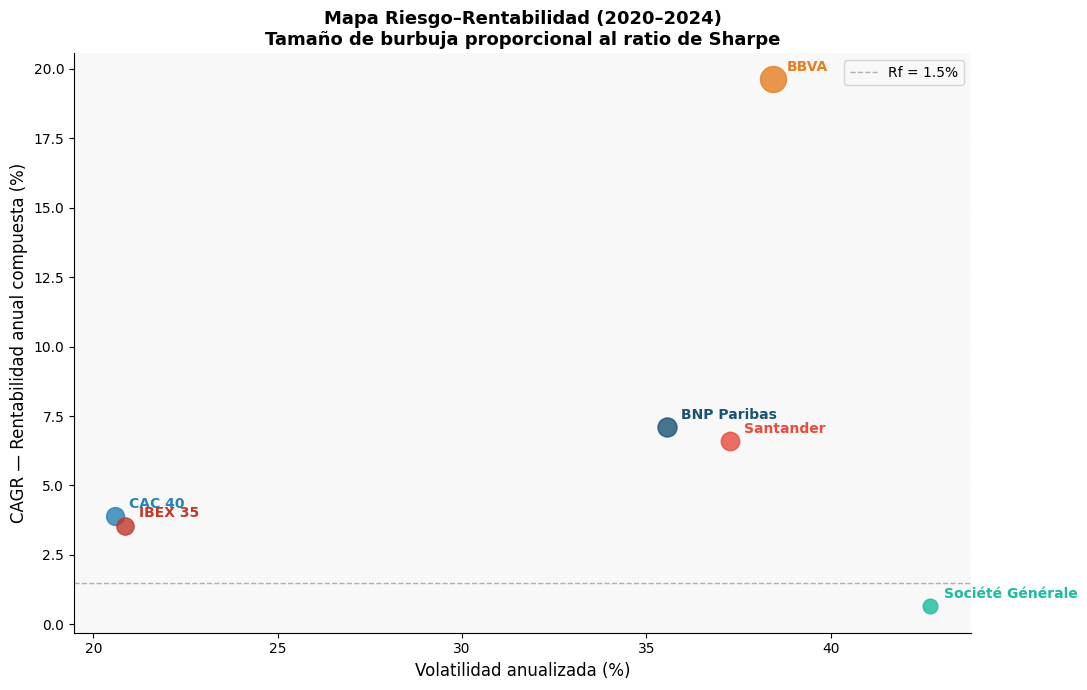

✓ Guardado: mapa_riesgo_rentabilidad.png


In [19]:
# ── CELDA 17: Tabla resumen y visualización de KPIs ───────────────────────────
# Consolidamos todos los KPIs en un único DataFrame para facilitar
# la comparación y la exportación al informe.

kpis = pd.DataFrame({
    'Ret. Acumulado (%)': retorno_acumulado.round(2),
    'CAGR (%)':           cagr.round(2),
    'Vol. Anual (%)':     (vol_anual * 100).round(2),
    'Sharpe':             sharpe.round(3),
    'Sortino':            sortino.round(3),
    'Beta':               pd.Series(betas).round(3),
    'Alpha anual (%)':    (pd.Series(alphas) * 100).round(2),
})

print("TABLA RESUMEN DE KPIs — IBEX 35 vs CAC 40 (2020-2024)")
print("=" * 85)
print(kpis.to_string())
print("=" * 85)

# ── Gráfico de burbujas: Riesgo vs Rentabilidad ────────────────────────────────
fig, ax = plt.subplots(figsize=(11, 7))

colores_activos = {
    'IBEX 35':          '#C0392B',
    'CAC 40':           '#2980B9',
    'Santander':        '#E74C3C',
    'BBVA':             '#E67E22',
    'BNP Paribas':      '#1A5276',
    'Société Générale': '#1ABC9C',
}

for activo in kpis.index:
    x = kpis.loc[activo, 'Vol. Anual (%)']
    y = kpis.loc[activo, 'CAGR (%)']
    s = abs(kpis.loc[activo, 'Sharpe']) * 600 + 100
    color = colores_activos[activo]

    ax.scatter(x, y, s=s, color=color, alpha=0.8, zorder=5)
    ax.annotate(activo, (x, y),
                textcoords="offset points", xytext=(10, 6),
                fontsize=10, color=color, fontweight='bold')

# Línea de Sharpe = 0 (rentabilidad = tipo libre de riesgo)
ax.axhline(RF_ANUAL * 100, color='gray', linestyle='--',
           linewidth=1, alpha=0.6, label=f'Rf = {RF_ANUAL*100:.1f}%')

ax.set_xlabel('Volatilidad anualizada (%)', fontsize=12)
ax.set_ylabel('CAGR — Rentabilidad anual compuesta (%)', fontsize=12)
ax.set_title('Mapa Riesgo–Rentabilidad (2020–2024)\n'
             'Tamaño de burbuja proporcional al ratio de Sharpe',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.4)

plt.tight_layout()
plt.savefig('mapa_riesgo_rentabilidad.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Guardado: mapa_riesgo_rentabilidad.png")

In [20]:
# Capítulo 5

In [21]:
# ── CELDA 18: Event Study ─────────────────────────────────────────────────────
# Para cada evento calculamos los retornos anormales acumulados (CAR)
# en una ventana de ±5 días alrededor de la fecha del evento.
# Retorno anormal = retorno observado - retorno esperado (media histórica)

eventos = {
    'COVID crash':          '2020-03-12',
    'Vacuna Pfizer':        '2020-11-09',
    'Invasión Ucrania':     '2022-02-24',
    'BCE primera subida':   '2022-07-21',
    'Impuesto banca ESP':   '2022-10-24',
    'Crisis SVB':           '2023-03-10',
}

ventana = 5   # días antes y después del evento
# Media histórica de retorno diario (estimada sobre todo el período)
ret_medio = retornos.mean()

resultados_es = []

for evento, fecha_str in eventos.items():
    fecha = pd.Timestamp(fecha_str)
    # Localizar posición en el índice
    idx = retornos.index.searchsorted(fecha)
    inicio = max(0, idx - ventana)
    fin    = min(len(retornos), idx + ventana + 1)

    ventana_ret = retornos.iloc[inicio:fin]

    for activo in retornos.columns:
        # Retornos anormales = observado - media histórica
        ar = ventana_ret[activo] - ret_medio[activo]
        car = ar.sum() * 100   # CAR en %
        resultados_es.append({
            'Evento':  evento,
            'Activo':  activo,
            'Fecha':   fecha_str,
            'CAR (%)': round(car, 2),
            'N días':  len(ventana_ret)
        })

df_es = pd.DataFrame(resultados_es)

# Pivot para visualización clara
pivot_es = df_es.pivot(index='Evento', columns='Activo', values='CAR (%)')
# Reordenar columnas
cols_order = ['IBEX 35','CAC 40','Santander','BBVA','BNP Paribas','Société Générale']
pivot_es = pivot_es[cols_order]

print("RETORNOS ANORMALES ACUMULADOS (CAR) — Ventana ±5 días (%)")
print("=" * 90)
print(pivot_es.to_string())
print("=" * 90)
print("\nValores negativos = impacto negativo sobre el activo en la ventana del evento")
print("Valores positivos = impacto positivo sobre el activo en la ventana del evento")

RETORNOS ANORMALES ACUMULADOS (CAR) — Ventana ±5 días (%)
Activo              IBEX 35  CAC 40  Santander   BBVA  BNP Paribas  Société Générale
Evento                                                                              
BCE primera subida     1.60    5.33      -0.99   0.20         4.21              5.93
COVID crash          -33.30  -35.05     -48.09 -44.16       -44.39            -56.11
Crisis SVB            -6.89   -5.22     -16.29 -19.23       -20.69            -22.29
Impuesto banca ESP     7.34    5.33       5.50   8.53         7.21              4.42
Invasión Ucrania      -8.82   -8.96     -16.60 -14.10       -21.50            -38.25
Vacuna Pfizer         21.18   17.31      35.77  38.83        30.45             33.56

Valores negativos = impacto negativo sobre el activo en la ventana del evento
Valores positivos = impacto positivo sobre el activo en la ventana del evento


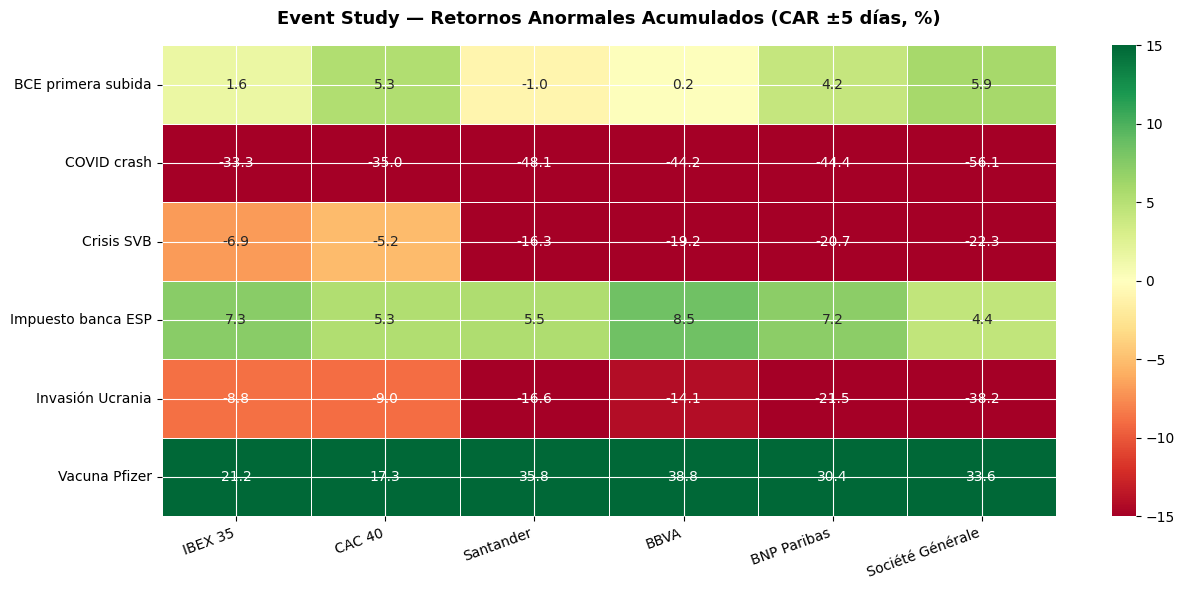

✓ Guardado: event_study_heatmap.png


In [22]:
# ── CELDA 19: Heatmap del Event Study ─────────────────────────────────────────
fig, ax = plt.subplots(figsize=(13, 6))

sns.heatmap(
    pivot_es,
    annot=True, fmt='.1f',
    cmap='RdYlGn',
    center=0,
    vmin=-15, vmax=15,
    linewidths=0.5, linecolor='white',
    ax=ax,
    annot_kws={'size': 10}
)

ax.set_title('Event Study — Retornos Anormales Acumulados (CAR ±5 días, %)',
             fontsize=13, fontweight='bold', pad=15)
ax.set_xlabel('')
ax.set_ylabel('')
plt.xticks(rotation=20, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig('event_study_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Guardado: event_study_heatmap.png")

In [23]:
# Paso 6

In [24]:
# ── CELDA 20: Exportar dataset completo para Power BI ─────────────────────────
# Creamos un Excel con múltiples hojas, cada una con un dataset distinto.
# Power BI importará cada hoja como una tabla independiente.

from datetime import datetime

# Necesitamos recalcular el drawdown para exportarlo como serie temporal
def drawdown_serie(precio_serie):
    rolling_max = precio_serie.cummax()
    return (precio_serie - rolling_max) / rolling_max * 100

# ── Hoja 1: Precios de cierre (base 100) ──────────────────────────────────────
df_base100 = base_100.copy()
df_base100.index.name = 'Fecha'
df_base100 = df_base100.reset_index()

# ── Hoja 2: Retornos logarítmicos diarios ─────────────────────────────────────
df_retornos = retornos.copy()
df_retornos.index.name = 'Fecha'
df_retornos = df_retornos.reset_index()
# Convertir a porcentaje para legibilidad en Power BI
for col in retornos.columns:
    df_retornos[col] = df_retornos[col] * 100

# ── Hoja 3: Volatilidad rolling 30 días ───────────────────────────────────────
df_vol = vol_30d.copy()
df_vol.index.name = 'Fecha'
df_vol = df_vol.reset_index()

# ── Hoja 4: Drawdown serie temporal ───────────────────────────────────────────
dd_dict = {'Fecha': precios.index}
for col in precios.columns:
    dd_dict[col] = drawdown_serie(precios[col]).values
df_drawdown = pd.DataFrame(dd_dict)

# ── Hoja 5: KPIs resumen (tabla plana — la más importante para Power BI) ──────
kpis_export = kpis.copy().reset_index()
kpis_export.columns = ['Activo', 'Ret_Acumulado_pct', 'CAGR_pct',
                        'Vol_Anual_pct', 'Sharpe', 'Sortino',
                        'Beta', 'Alpha_Anual_pct']

# Añadimos columna de tipo de activo y país para usar como filtros en Power BI
kpis_export['Tipo']  = kpis_export['Activo'].map({
    'IBEX 35':          'Índice',
    'CAC 40':           'Índice',
    'Santander':        'Banco',
    'BBVA':             'Banco',
    'BNP Paribas':      'Banco',
    'Société Générale': 'Banco',
})
kpis_export['País'] = kpis_export['Activo'].map({
    'IBEX 35':          'España',
    'CAC 40':           'Francia',
    'Santander':        'España',
    'BBVA':             'España',
    'BNP Paribas':      'Francia',
    'Société Générale': 'Francia',
})

# Añadimos drawdown máximo
mdd_dict = {}
rec_dict = {}
for col in precios.columns:
    info = max_drawdown_info(precios[col])
    mdd_dict[col] = info['MDD (%)']
    rec_dict[col] = info['Días recuper.']

kpis_export['MDD_pct']       = kpis_export['Activo'].map(mdd_dict)
kpis_export['Dias_Rec_MDD']  = kpis_export['Activo'].map(rec_dict)

# ── Hoja 6: Event study ────────────────────────────────────────────────────────
df_es_export = df_es.copy()

# ── Hoja 7: Correlaciones ──────────────────────────────────────────────────────
df_corr = corr_matrix.reset_index()
df_corr.columns.name = None

# ── Hoja 8: Eventos (tabla de referencia para anotaciones en gráficos) ─────────
df_eventos = pd.DataFrame({
    'Evento':    list(eventos.keys()),
    'Fecha':     [pd.Timestamp(f) for f in eventos.values()],
    'Fecha_str': list(eventos.values()),
    'Tipo':      ['Sanitario','Sanitario','Geopolítico','Monetario','Político','Sistémico'],
    'Signo':     ['Negativo','Positivo','Negativo','Mixto','Mixto','Negativo'],
})

# ── Exportar a Excel ──────────────────────────────────────────────────────────
nombre_archivo = 'TFG_PowerBI_Dataset.xlsx'

with pd.ExcelWriter(nombre_archivo, engine='openpyxl') as writer:
    df_base100.to_excel(writer,     sheet_name='1_Base100',        index=False)
    df_retornos.to_excel(writer,    sheet_name='2_Retornos_pct',   index=False)
    df_vol.to_excel(writer,         sheet_name='3_Volatilidad',    index=False)
    df_drawdown.to_excel(writer,    sheet_name='4_Drawdown',       index=False)
    kpis_export.to_excel(writer,    sheet_name='5_KPIs_Resumen',   index=False)
    df_es_export.to_excel(writer,   sheet_name='6_EventStudy',     index=False)
    df_corr.to_excel(writer,        sheet_name='7_Correlaciones',  index=False)
    df_eventos.to_excel(writer,     sheet_name='8_Eventos',        index=False)

print(f"✓ Archivo exportado: {nombre_archivo}")
print(f"\nHojas creadas:")
print(f"  1_Base100        → {df_base100.shape[0]} filas × {df_base100.shape[1]} cols")
print(f"  2_Retornos_pct   → {df_retornos.shape[0]} filas × {df_retornos.shape[1]} cols")
print(f"  3_Volatilidad    → {df_vol.shape[0]} filas × {df_vol.shape[1]} cols")
print(f"  4_Drawdown       → {df_drawdown.shape[0]} filas × {df_drawdown.shape[1]} cols")
print(f"  5_KPIs_Resumen   → {kpis_export.shape[0]} filas × {kpis_export.shape[1]} cols")
print(f"  6_EventStudy     → {df_es_export.shape[0]} filas × {df_es_export.shape[1]} cols")
print(f"  7_Correlaciones  → {df_corr.shape[0]} filas × {df_corr.shape[1]} cols")
print(f"  8_Eventos        → {df_eventos.shape[0]} filas × {df_eventos.shape[1]} cols")

✓ Archivo exportado: TFG_PowerBI_Dataset.xlsx

Hojas creadas:
  1_Base100        → 1282 filas × 7 cols
  2_Retornos_pct   → 1281 filas × 7 cols
  3_Volatilidad    → 1281 filas × 7 cols
  4_Drawdown       → 1282 filas × 7 cols
  5_KPIs_Resumen   → 6 filas × 12 cols
  6_EventStudy     → 36 filas × 5 cols
  7_Correlaciones  → 6 filas × 7 cols
  8_Eventos        → 6 filas × 5 cols


In [25]:
# ── CELDA 21: Descarga del archivo ────────────────────────────────────────────
from google.colab import files
files.download('TFG_PowerBI_Dataset.xlsx')
print("✓ Descarga iniciada — revisa tu carpeta de Descargas")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✓ Descarga iniciada — revisa tu carpeta de Descargas
